<h1 align='center' style='color:blue'>Codebasics ML Course: Credit Risk Modeling Project</h1>

In [282]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set float display format for pandas
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set numpy print options||
np.set_printoptions(suppress=True, precision=2)

In [4]:
df_customers = pd.read_csv('dataset/customers.csv')
df_loans = pd.read_csv('dataset/loans.csv')
df_bureau = pd.read_csv('dataset/bureau_data.csv')

In [6]:
df_customers.shape, df_loans.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [8]:
df=pd.merge(df_customers, df_loans, on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [10]:
df

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,40,F,Single,Salaried,775000,2,Owned,11,Chennai,...,535000,10700.00,96300,428000,22,385199,178470,2024-07-22,2024-08-15,False
49996,C49997,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,...,3243000,64860.00,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,False
49997,C49998,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,...,3740000,74800.00,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,False
49998,C49999,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,...,1630000,32600.00,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,False


In [12]:
X = df.drop('default', axis='columns')
y= df.default
y

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Name: default, Length: 50000, dtype: bool

In [14]:
X

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,40,F,Single,Salaried,775000,2,Owned,11,Chennai,...,610000,535000,10700.00,96300,428000,22,385199,178470,2024-07-22,2024-08-15
49996,C49997,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,...,4211000,3243000,64860.00,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29
49997,C49998,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,...,4097000,3740000,74800.00,673200,2992000,37,912691,355461,2024-07-22,2024-07-25
49998,C49999,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,...,1871000,1630000,32600.00,293400,1304000,37,300035,179453,2024-07-22,2024-07-29


In [16]:
from sklearn.model_selection import train_test_split

In [18]:
X.shape

(50000, 25)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=45)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((37500, 25), (12500, 25), (37500,), (12500,))

In [24]:
df = pd.merge(df, df_bureau)
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [28]:
df['default']=df['default'].astype(int)

In [30]:
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [32]:
X = df.drop('default', axis='columns')
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=45)

In [34]:
df_train = pd.concat([X_train, y_train], axis='columns')
df_test = pd.concat([X_test, y_test], axis='columns')

In [36]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
318,C00319,43,M,Single,Salaried,1159000,0,Owned,17,Jaipur,...,2019-08-05,2019-08-21,1,2,5,2,11,6,41,0
10969,C10970,44,F,Single,Self-Employed,9169000,0,Mortgage,1,Hyderabad,...,2020-08-28,2020-09-16,4,2,182,5,28,7,12,0
1654,C01655,43,F,Single,Self-Employed,1229000,1,Owned,22,Kolkata,...,2019-09-23,2019-09-29,4,1,66,0,0,8,13,0
10545,C10546,44,F,Married,Salaried,2229000,3,Mortgage,3,Chennai,...,2020-08-12,2020-08-25,3,1,68,9,47,5,39,0
43712,C43713,39,M,Single,Self-Employed,1218000,0,Mortgage,7,Ahmedabad,...,2023-12-06,2023-12-24,2,2,87,0,0,2,36,0


In [38]:
df_train.shape, df_test.shape

((37500, 33), (12500, 33))

In [40]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 43
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [42]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [44]:
mode_resisdence = df_train.residence_type.mode()[0]
mode_resisdence

'Owned'

In [46]:
df_train.residence_type.fillna(mode_resisdence, inplace=True)

In [48]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [50]:
df_test.residence_type.fillna(mode_resisdence, inplace=True)

In [52]:
df_train.duplicated().sum()

np.int64(0)

In [54]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [56]:

# Assuming df_train is already loaded

# Continuous (numeric) columns
columns_continuous = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical (non-numeric) columns
columns_categorical = df_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print("Continuous columns:", columns_continuous)
print("\nCategorical columns:", columns_categorical)

Continuous columns: ['age', 'income', 'number_of_dependants', 'years_at_current_address', 'zipcode', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default']

Categorical columns: ['cust_id', 'gender', 'marital_status', 'employment_status', 'residence_type', 'city', 'state', 'loan_id', 'loan_purpose', 'loan_type', 'disbursal_date', 'installment_start_dt']


In [58]:
columns_continuous  = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                       'sanction_amount', 'loan_amount','processing_fee', 'gst', 'net_disbursement', 
                       'loan_tenure_months', 'principal_outstanding','bank_balance_at_application', 
                       'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months','delinquent_months', 
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['cust_id', 'gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

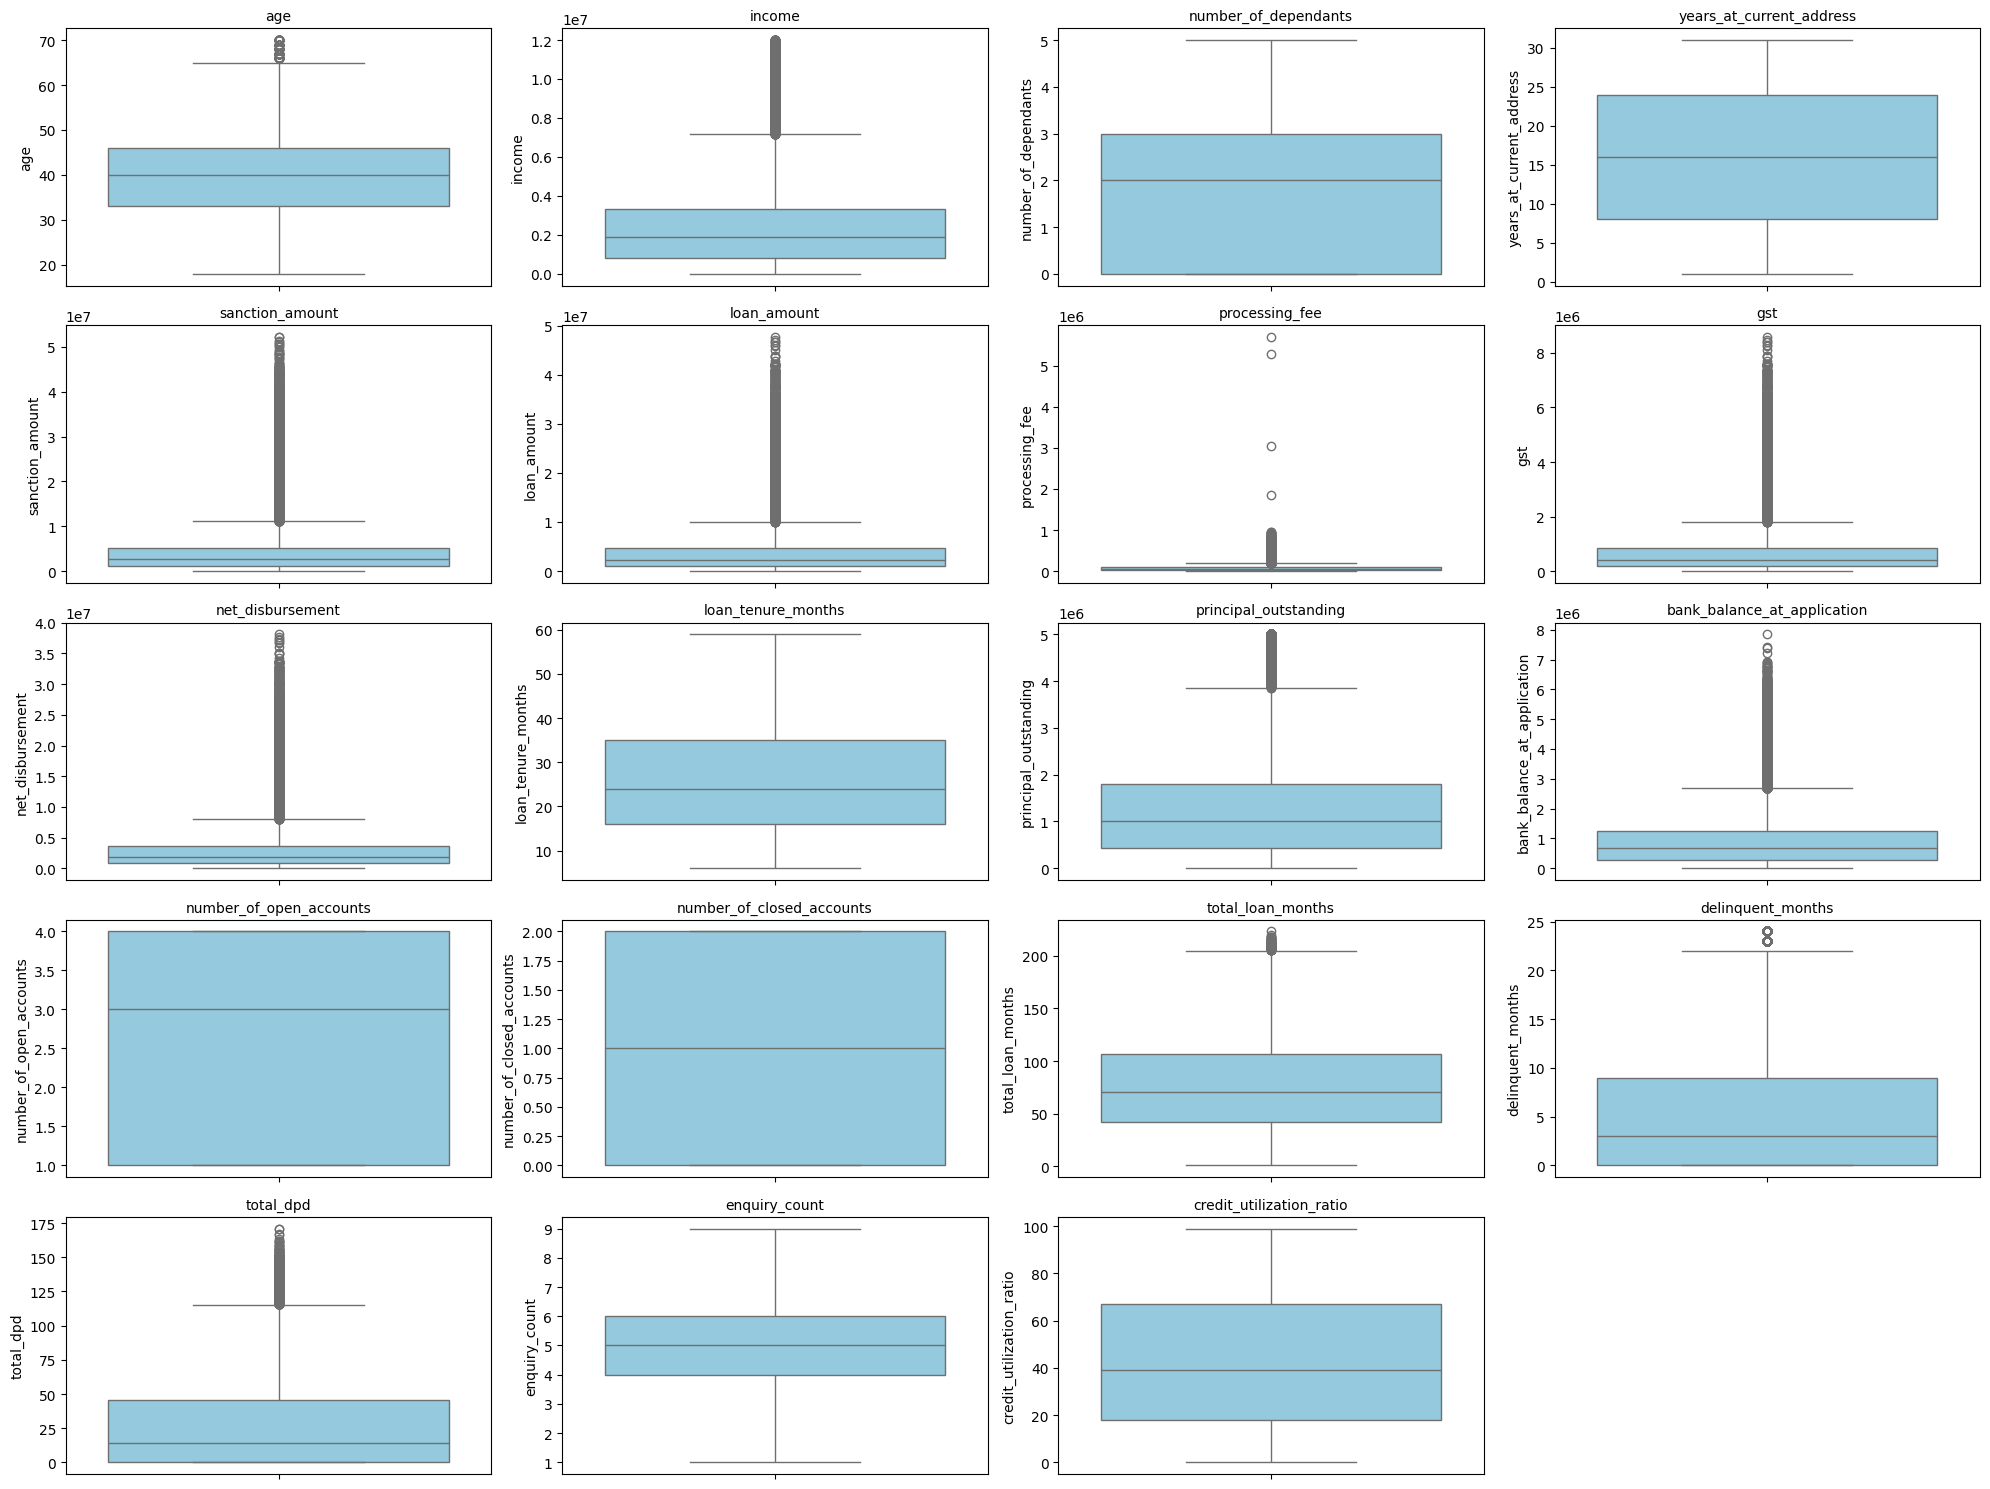

In [60]:
# Set figure size for readability
plt.figure(figsize=(20, 15))

# Loop through columns and create subplots
for i, col in enumerate(columns_continuous, 1):
    plt.subplot(5, 4, i)  # 5 rows, 4 columns grid
    sns.boxplot(y=df_train[col], color="skyblue")
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

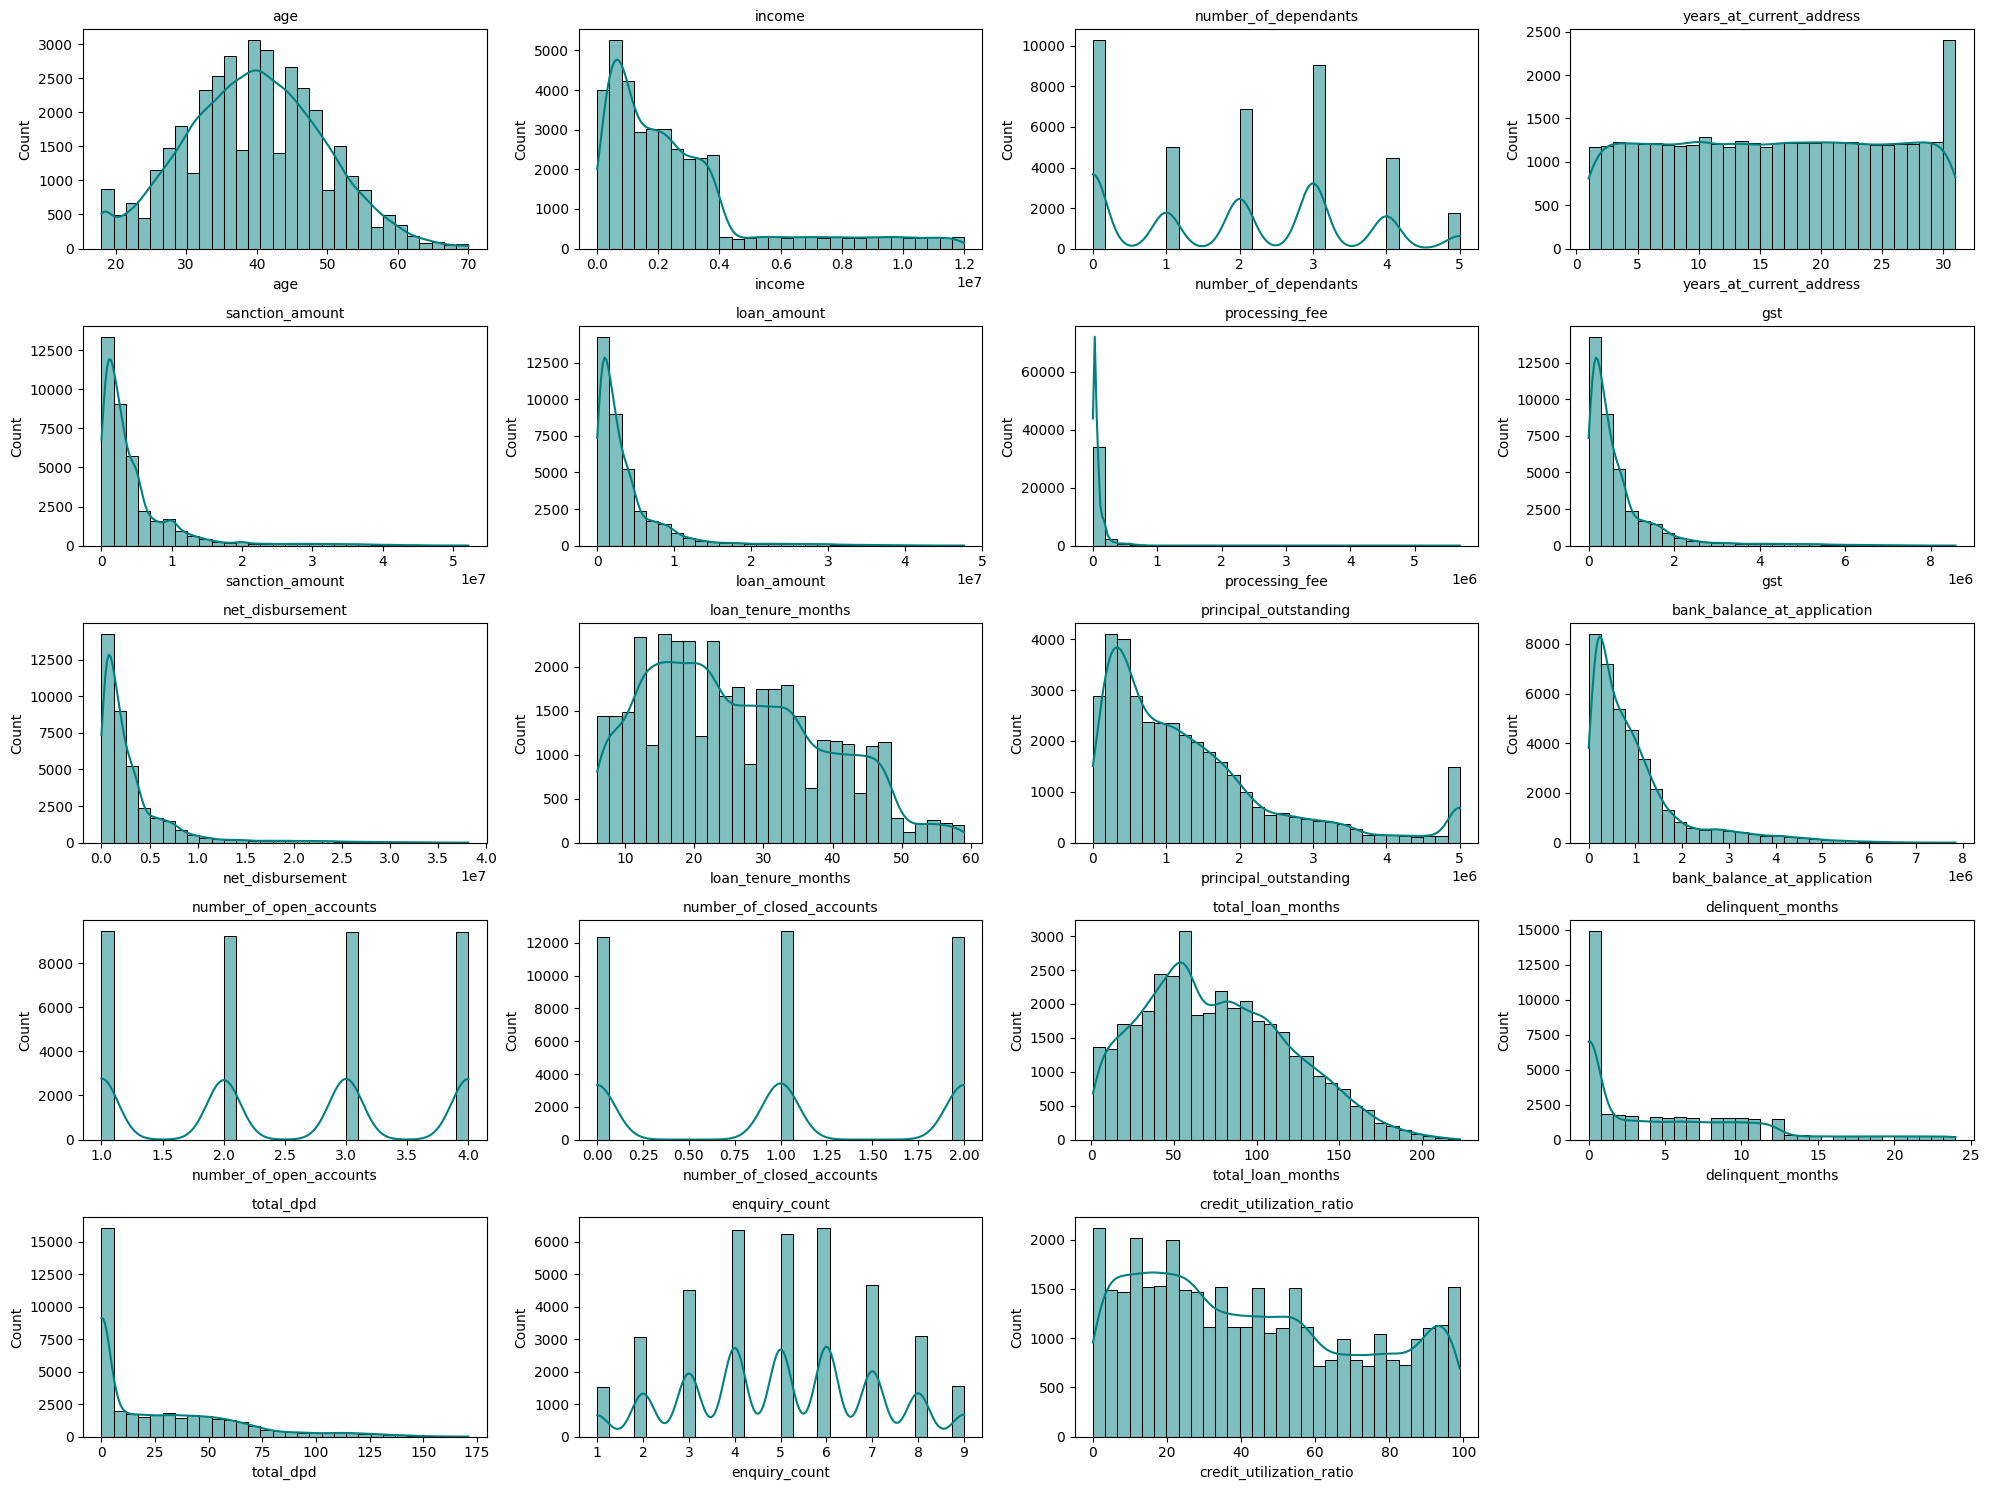

In [61]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(columns_continuous, 1):
    plt.subplot(5, 4, i)  # 5 rows, 4 columns grid
    sns.histplot(df_train[col], kde=True, bins=30, color="teal")
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

In [62]:
df_train.processing_fee.describe()

count     37500.00
mean      80441.71
std      115285.97
min           0.00
25%       19395.00
50%       45120.00
75%       92380.00
max     5698029.90
Name: processing_fee, dtype: float64

In [64]:
df_train[df_train.processing_fee > df_train.loan_amount][['processing_fee', 'loan_amount']]

,processing_fee,loan_amount
12294,5698029.90,4639000
9898,5293543.52,3626000
47089,1858964.77,1738000
29305,3036378.01,2616000


In [65]:
df_train[(df_train.processing_fee / df_train.loan_amount)>0.03][['processing_fee', 'loan_amount']]

,processing_fee,loan_amount
12294,5698029.90,4639000
9898,5293543.52,3626000
47089,1858964.77,1738000
29305,3036378.01,2616000


In [70]:
df_train_1 =df_train[(df_train.processing_fee / df_train.loan_amount)<0.03].copy()
df_train_1.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
318,C00319,43,M,Single,Salaried,1159000,0,Owned,17,Jaipur,...,2019-08-05,2019-08-21,1,2,5,2,11,6,41,0
10969,C10970,44,F,Single,Self-Employed,9169000,0,Mortgage,1,Hyderabad,...,2020-08-28,2020-09-16,4,2,182,5,28,7,12,0
1654,C01655,43,F,Single,Self-Employed,1229000,1,Owned,22,Kolkata,...,2019-09-23,2019-09-29,4,1,66,0,0,8,13,0
10545,C10546,44,F,Married,Salaried,2229000,3,Mortgage,3,Chennai,...,2020-08-12,2020-08-25,3,1,68,9,47,5,39,0
43712,C43713,39,M,Single,Self-Employed,1218000,0,Mortgage,7,Ahmedabad,...,2023-12-06,2023-12-24,2,2,87,0,0,2,36,0


In [72]:
df_test_1 =df_test[(df_test.processing_fee / df_test.loan_amount)<0.03].copy()
df_test_1.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
37921,C37922,27,M,Married,Self-Employed,2488000,3,Rented,23,Delhi,...,2023-05-08,2023-05-23,3,1,104,0,0,5,5,0
16114,C16115,55,M,Married,Self-Employed,701000,3,Owned,5,Lucknow,...,2021-03-03,2021-03-30,4,0,122,1,1,5,97,0
5539,C05540,49,F,Married,Self-Employed,4724000,2,Owned,3,Mumbai,...,2020-02-11,2020-03-12,4,0,144,0,0,7,59,0
29703,C29704,37,M,Single,Self-Employed,2771000,0,Mortgage,4,Jaipur,...,2022-07-12,2022-08-04,2,1,47,1,6,3,19,0
24870,C24871,28,M,Married,Salaried,2382000,3,Owned,22,Jaipur,...,2022-01-17,2022-01-27,1,0,17,0,0,1,53,0


In [74]:
for col in columns_categorical:
    print(col, "#####", df_train_1[col]. unique())

cust_id ##### ['C00319' 'C10970' 'C01655' ... 'C46299' 'C39084' 'C22640']
gender ##### ['M' 'F']
marital_status ##### ['Single' 'Married']
employment_status ##### ['Salaried' 'Self-Employed']
residence_type ##### ['Owned' 'Mortgage' 'Rented']
city ##### ['Jaipur' 'Hyderabad' 'Kolkata' 'Chennai' 'Ahmedabad' 'Pune' 'Lucknow'
 'Mumbai' 'Bangalore' 'Delhi']
state ##### ['Rajasthan' 'Telangana' 'West Bengal' 'Tamil Nadu' 'Gujarat'
 'Maharashtra' 'Uttar Pradesh' 'Karnataka' 'Delhi']
zipcode ##### [302001 500001 700001 600001 380001 411001 226001 400001 560001 110001]
loan_purpose ##### ['Personal' 'Auto' 'Home' 'Education' 'Personaal']
loan_type ##### ['Unsecured' 'Secured']
default ##### [0 1]


In [76]:
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal', 'Personal')
df_test_1['loan_purpose'] = df_test_1['loan_purpose'].replace('Personaal', 'Personal')

In [78]:
df_train_1['loan_purpose'].unique()

array(['Personal', 'Auto', 'Home', 'Education'], dtype=object)

<h3 align="center" style="color:DarkBlue; font-weight:bold; text-decoration:underline;">
Exploratory Data Analysis
</h3>

In [81]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

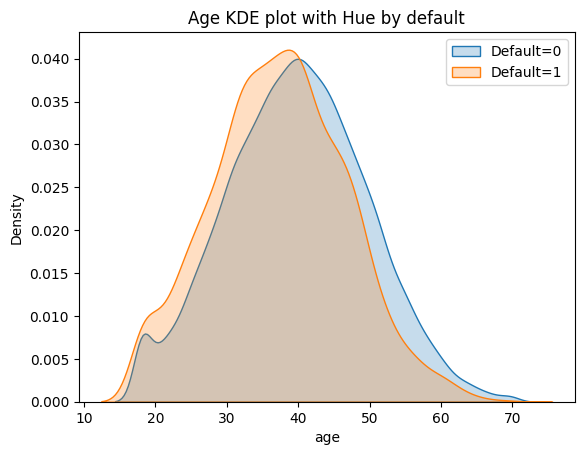

In [83]:
sns.kdeplot(df_train[df_train.default==0]['age'], fill=True, label='Default=0')
sns.kdeplot(df_train[df_train.default==1]['age'], fill=True, label='Default=1')
plt.title(f"Age KDE plot with Hue by default")
plt.legend()
plt.show()

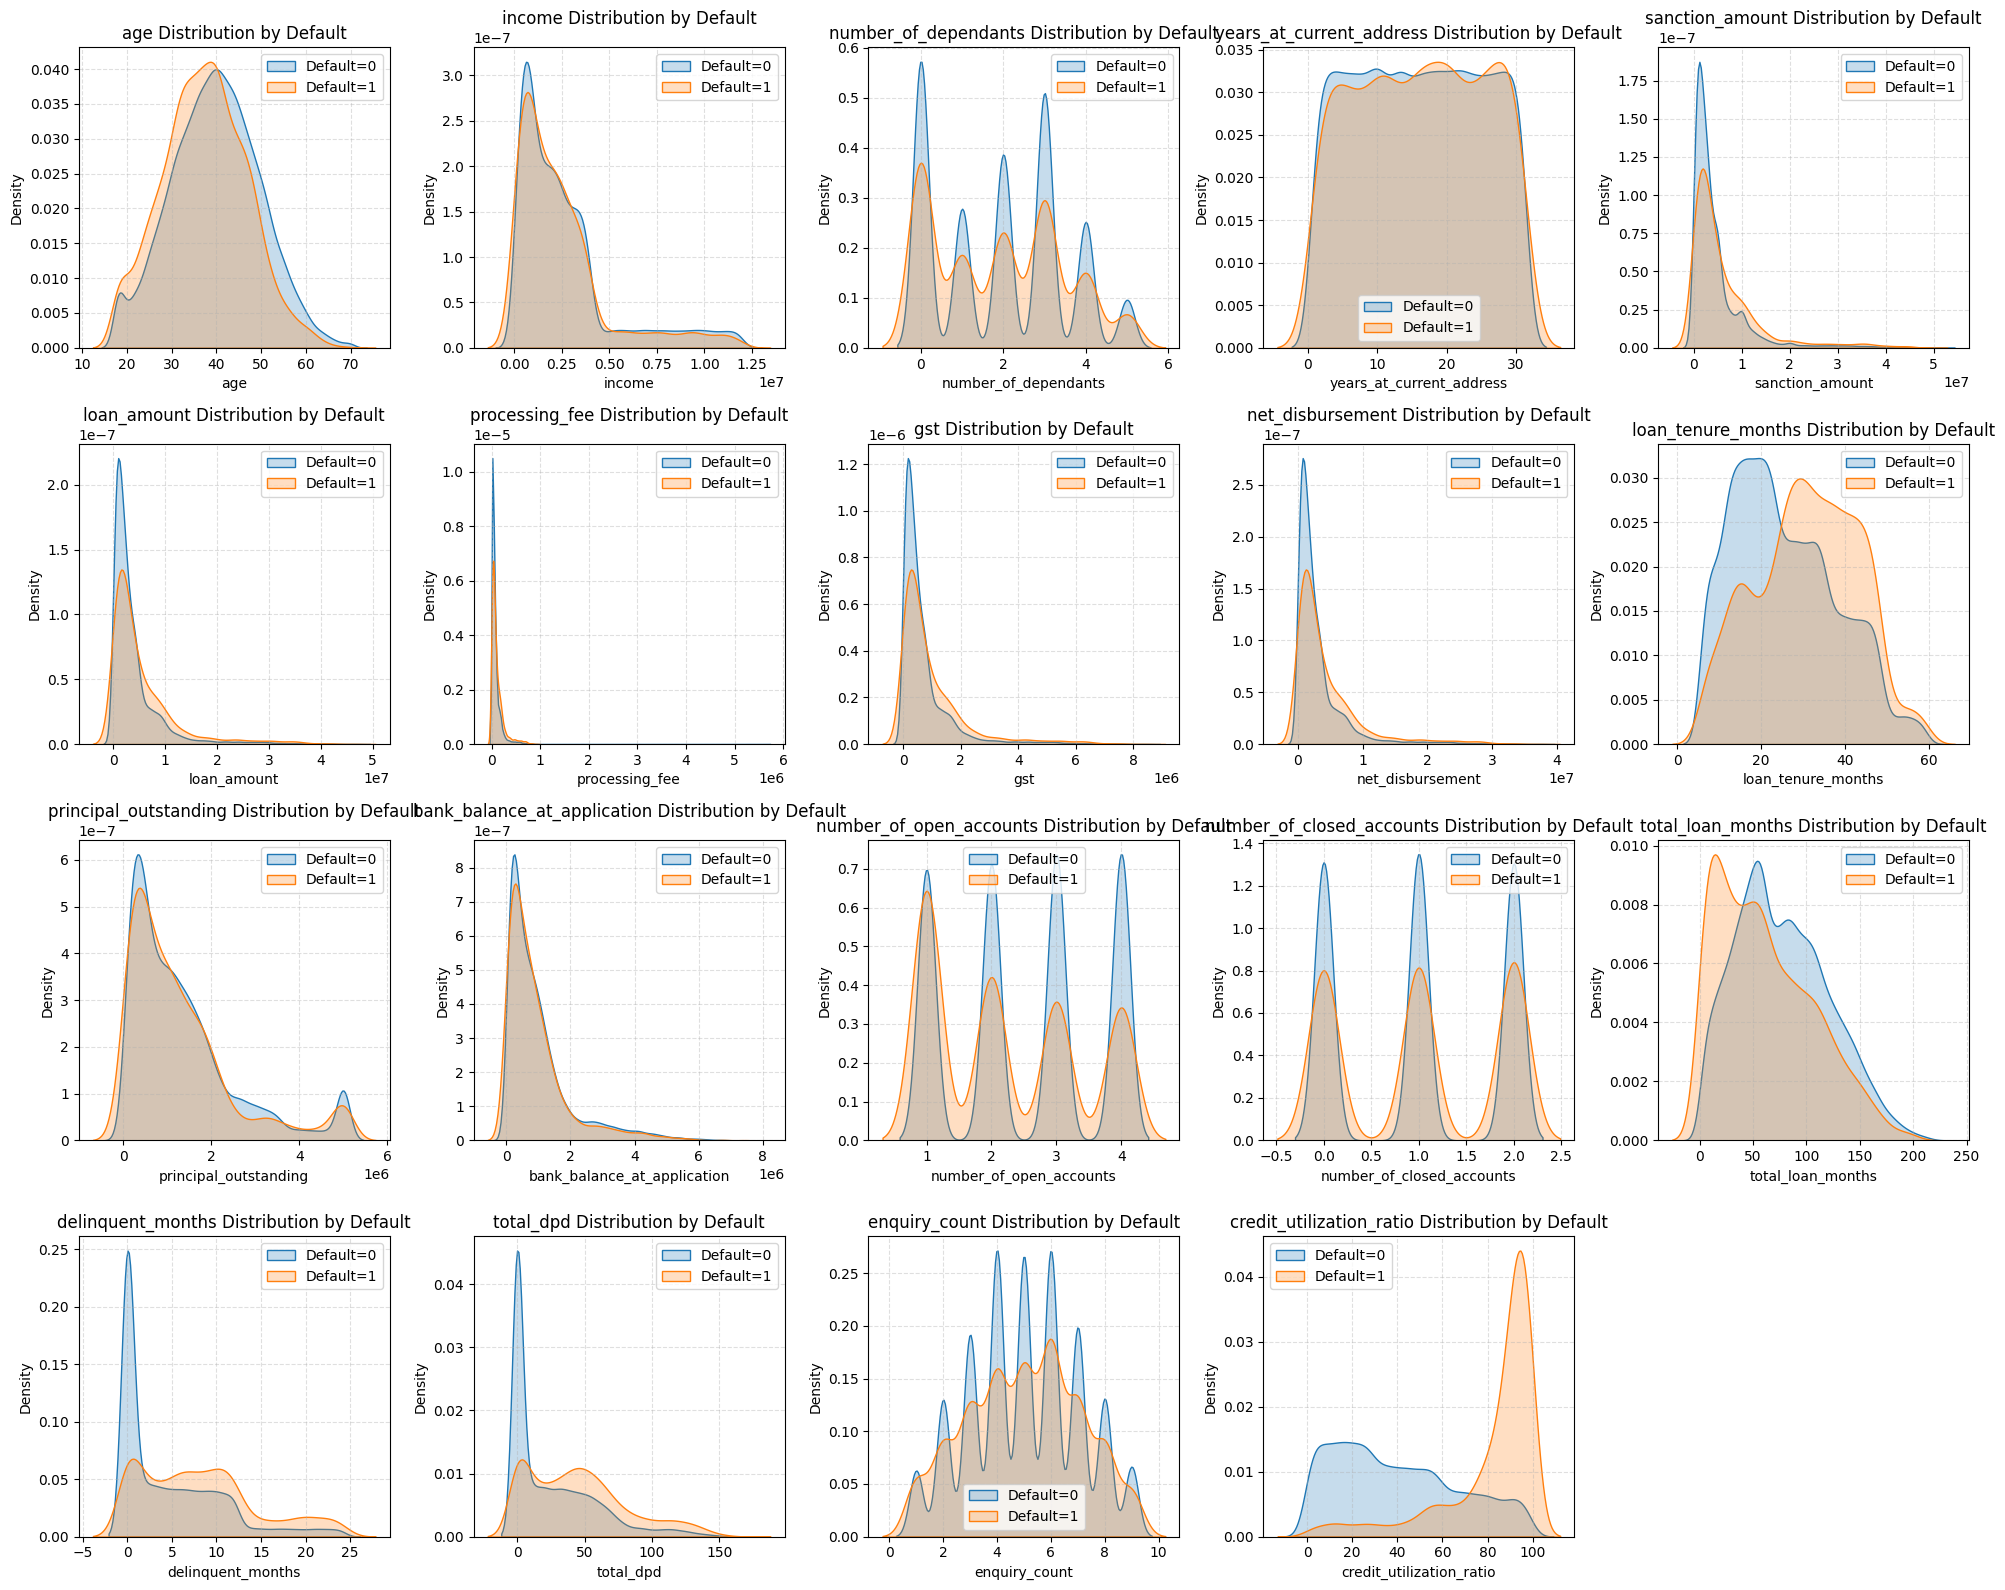

In [85]:
# Plot setup
fig, axes = plt.subplots(4, 5, figsize=(20, 16))  # 4x5 grid
axes = axes.flatten()

for i, col in enumerate(columns_continuous):
    ax = axes[i]
    sns.kdeplot(df_train[df_train['default'] == 0][col], fill=True, label='Default=0', ax=ax)
    sns.kdeplot(df_train[df_train['default'] == 1][col], fill=True, label='Default=1', ax=ax)
    ax.set_title(f'{col} Distribution by Default')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

# Hide any unused subplots (if < 20 columns)
for j in range(len(columns_continuous), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<h3 align="center" style="color:DarkBlue; font-weight:bold; text-decoration:underline;">
Feature Engineering
</h3>

In [89]:
df_train_1['loan_to_income'] = round(df_train_1['loan_amount']/df_train_1['income'], 2)
df_test_1['loan_to_income'] = round(df_test_1['loan_amount']/df_test_1['income'], 2)
df_train_1['loan_to_income'].describe()

count   37490.00
mean        1.55
std         0.97
min         0.30
25%         0.77
50%         1.15
75%         2.45
max         4.59
Name: loan_to_income, dtype: float64

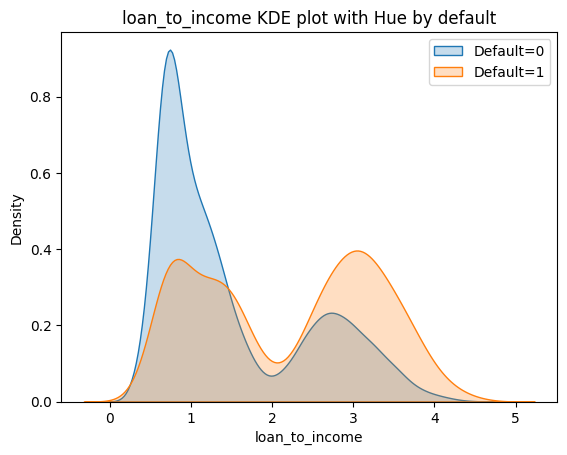

In [91]:
sns.kdeplot(df_train_1[df_train_1.default==0]['loan_to_income'], fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default==1]['loan_to_income'], fill=True, label='Default=1')
plt.title(f"loan_to_income KDE plot with Hue by default")
plt.legend()
plt.show()

In [94]:
df_train_1[['delinquent_months','total_loan_months' ]]

,delinquent_months,total_loan_months
318,2,5
10969,5,182
1654,0,66
10545,9,68
43712,0,87
...,...,...
17133,0,108
35238,6,182
46298,2,129
39083,0,99


In [96]:
df_train_1['delinquency_ratio'] = (df_train_1['delinquent_months']*100/df_train_1['total_loan_months']).round(1)
df_test_1['delinquency_ratio'] = (df_test_1['delinquent_months']*100/df_test_1['total_loan_months']).round(1)

In [98]:
df_train_1['delinquency_ratio'] 

318     40.00
10969    2.70
1654     0.00
10545   13.20
43712    0.00
         ... 
17133    0.00
35238    3.30
46298    1.60
39083    0.00
22639    4.10
Name: delinquency_ratio, Length: 37490, dtype: float64

In [100]:
df_train_1[['delinquent_months','total_loan_months', 'delinquency_ratio' ]].head()

,delinquent_months,total_loan_months,delinquency_ratio
318,2,5,40.00
10969,5,182,2.70
1654,0,66,0.00
10545,9,68,13.20
43712,0,87,0.00


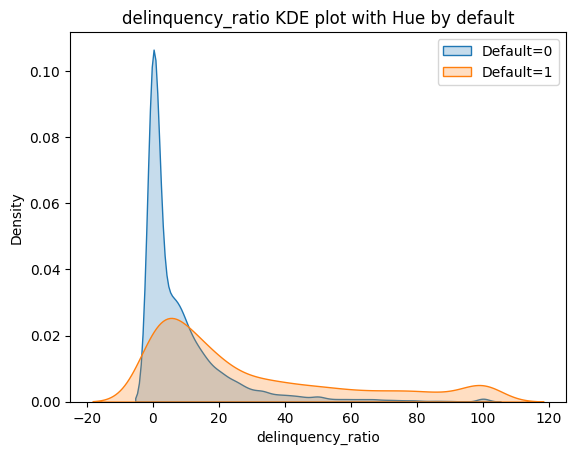

In [102]:
sns.kdeplot(df_train_1[df_train_1.default==0]['delinquency_ratio'], fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default==1]['delinquency_ratio'], fill=True, label='Default=1')
plt.title(f"delinquency_ratio KDE plot with Hue by default")
plt.legend()
plt.show()

In [104]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio'],
      dtype='object')

In [106]:
df_train_1['avg_dpd_per_delinquency'] = np.where(
    df_train_1['delinquent_months'] != 0,
    (df_train_1['total_dpd'] / df_train_1['delinquent_months']).round(1),
    0
)

In [108]:
df_test_1['avg_dpd_per_delinquency'] = np.where(
    df_test_1['delinquent_months'] != 0,
    (df_test_1['total_dpd'] / df_test_1['delinquent_months']).round(1),
    0
)

In [110]:
df_train_1['avg_dpd_per_delinquency'].isna().sum()

np.int64(0)

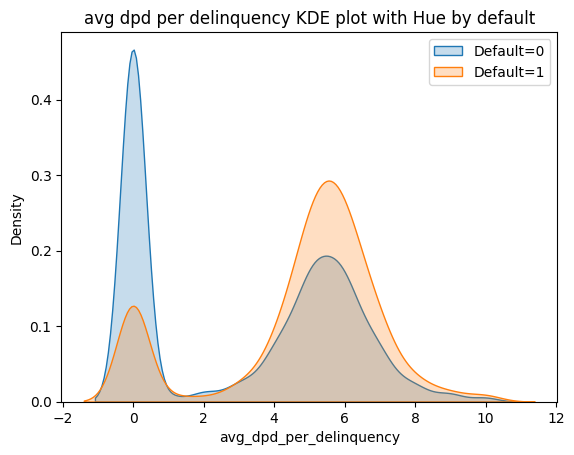

In [112]:
sns.kdeplot(df_train_1[df_train_1.default==0]['avg_dpd_per_delinquency'], fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default==1]['avg_dpd_per_delinquency'], fill=True, label='Default=1')
plt.title(f"avg dpd per delinquency KDE plot with Hue by default")
plt.legend()
plt.show()

In [114]:
df_train_1['credit_utilization_per_income'] = (df_train_1['credit_utilization_ratio']/df_train_1['loan_to_income']).round(1)
df_test_1['credit_utilization_per_income'] = (df_test_1['credit_utilization_ratio']/df_test_1['loan_to_income']).round(1)
df_train_1['credit_utilization_per_income']

318      59.40
10969    11.40
1654     12.00
10545    53.40
43712    46.80
         ...  
17133     4.10
35238     8.00
46298    25.40
39083     3.60
22639   125.90
Name: credit_utilization_per_income, Length: 37490, dtype: float64

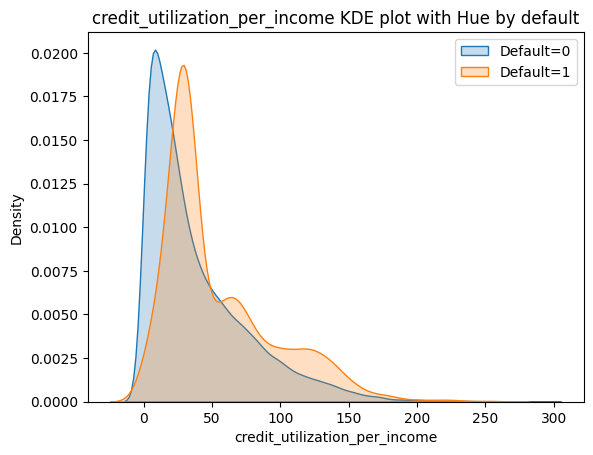

In [116]:
sns.kdeplot(df_train_1[df_train_1.default==0]['credit_utilization_per_income'], fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default==1]['credit_utilization_per_income'], fill=True, label='Default=1')
plt.title(f"credit_utilization_per_income KDE plot with Hue by default")
plt.legend()
plt.show()

### Feature Selection

In [119]:
df_train_2 = df_train_1.drop(['cust_id', 'loan_id'], axis=1)
df_test_2 = df_test_1.drop(['cust_id', 'loan_id'], axis=1)

In [121]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'],
      dtype='object')

In [123]:
df_train_3 = df_train_2.drop(['disbursal_date','installment_start_dt','loan_amount','income',
                              'total_loan_months', 'delinquent_months','total_dpd'], axis='columns')
df_test_3 = df_test_2.drop(['disbursal_date','installment_start_dt','loan_amount','income',
                              'total_loan_months', 'delinquent_months','total_dpd'], axis='columns')

In [125]:
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'],
      dtype='object')

### There is multicolinerity between these columns, lets find out what it is 

In [128]:
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'],
      dtype='object')

In [130]:
X_train = df_train_3.drop('default', axis='columns')
y_train = df_train_3['default']

X_train.T

,318,10969,1654,10545,43712,27992,7320,39774,29137,37599,...,19419,8507,33207,8290,17040,17133,35238,46298,39083,22639
age,43,44,43,44,39,41,46,40,50,38,...,28,31,37,39,37,36,39,63,33,53
gender,M,F,F,F,M,F,F,M,F,M,...,M,F,F,M,M,M,M,M,F,F
marital_status,Single,Single,Single,Married,Single,Single,Married,Single,Married,Married,...,Single,Single,Single,Married,Married,Married,Married,Married,Married,Married
employment_status,Salaried,Self-Employed,Self-Employed,Salaried,Self-Employed,Self-Employed,Self-Employed,Self-Employed,Self-Employed,Salaried,...,Self-Employed,Salaried,Salaried,Self-Employed,Self-Employed,Salaried,Self-Employed,Self-Employed,Self-Employed,Self-Employed
number_of_dependants,0,0,1,3,0,0,4,0,5,4,...,1,1,1,3,4,2,4,4,4,3
residence_type,Owned,Mortgage,Owned,Mortgage,Mortgage,Owned,Owned,Owned,Mortgage,Owned,...,Owned,Rented,Owned,Rented,Mortgage,Rented,Mortgage,Owned,Owned,Owned
years_at_current_address,17,1,22,3,7,31,31,26,24,14,...,4,3,29,24,30,9,17,21,19,2
city,Jaipur,Hyderabad,Kolkata,Chennai,Ahmedabad,Pune,Lucknow,Pune,Chennai,Mumbai,...,Delhi,Pune,Mumbai,Mumbai,Kolkata,Ahmedabad,Lucknow,Ahmedabad,Pune,Bangalore
state,Rajasthan,Telangana,West Bengal,Tamil Nadu,Gujarat,Maharashtra,Uttar Pradesh,Maharashtra,Tamil Nadu,Maharashtra,...,Delhi,Maharashtra,Maharashtra,Maharashtra,West Bengal,Gujarat,Uttar Pradesh,Gujarat,Maharashtra,Karnataka
zipcode,302001,500001,700001,600001,380001,411001,226001,411001,600001,400001,...,110001,411001,400001,400001,700001,380001,226001,380001,411001,560001


In [132]:
X_train.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income'],
      dtype='object')

In [134]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = X_train.select_dtypes(['int64', 'float64']).columns

cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income'],
      dtype='object')

In [136]:
scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.head(3)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
318,0.48,M,Single,Salaried,0.00,Owned,0.53,Jaipur,Rajasthan,0.33,...,0.11,0.05,0.00,1.00,0.62,0.41,0.09,0.40,0.55,0.20
10969,0.50,F,Single,Self-Employed,0.00,Mortgage,0.00,Hyderabad,Telangana,0.66,...,1.00,0.33,1.00,1.00,0.75,0.12,0.17,0.03,0.56,0.04
1654,0.48,F,Single,Self-Employed,0.20,Owned,0.70,Kolkata,West Bengal,1.00,...,0.17,0.03,1.00,0.50,0.88,0.13,0.18,0.00,0.00,0.04


In [138]:
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00,37490.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33,0.14
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29,0.13
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00,0.04
50%,0.42,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43,0.09
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.36,0.16,1.00,1.00,0.62,0.68,0.50,0.13,0.58,0.20
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [140]:
X_test.T

,37921,16114,5539,29703,24870,48222,42839,46074,20469,20104,...,34122,8421,45403,36461,17474,27074,27518,32988,10562,9007
cust_id,C37922,C16115,C05540,C29704,C24871,C48223,C42840,C46075,C20470,C20105,...,C34123,C08422,C45404,C36462,C17475,C27075,C27519,C32989,C10563,C09008
age,27,55,49,37,28,25,32,56,38,34,...,48,49,37,32,47,39,47,20,40,49
gender,M,M,F,M,M,M,M,M,M,F,...,F,F,M,F,M,F,F,F,F,M
marital_status,Married,Married,Married,Single,Married,Single,Single,Married,Single,Single,...,Married,Single,Married,Single,Single,Single,Single,Single,Married,Married
employment_status,Self-Employed,Self-Employed,Self-Employed,Self-Employed,Salaried,Salaried,Self-Employed,Self-Employed,Self-Employed,Self-Employed,...,Salaried,Self-Employed,Self-Employed,Self-Employed,Salaried,Salaried,Self-Employed,Salaried,Self-Employed,Salaried
income,2488000,701000,4724000,2771000,2382000,1563000,6912000,2589000,3763000,3936000,...,2002000,6564000,6943000,5712000,618000,3423000,2125000,574000,5311000,931000
number_of_dependants,3,3,2,0,3,0,0,2,0,1,...,2,1,3,0,0,0,0,0,2,3
residence_type,Rented,Owned,Owned,Mortgage,Owned,Owned,Mortgage,Mortgage,NaN,Mortgage,...,Owned,Mortgage,Owned,Owned,Owned,Rented,Rented,Owned,Rented,Rented
years_at_current_address,23,5,3,4,22,21,6,28,15,15,...,27,1,29,17,26,21,6,8,25,12
city,Delhi,Lucknow,Mumbai,Jaipur,Jaipur,Lucknow,Kolkata,Bangalore,Delhi,Delhi,...,Ahmedabad,Hyderabad,Hyderabad,Lucknow,Chennai,Kolkata,Lucknow,Jaipur,Hyderabad,Jaipur


In [142]:
X_test = df_test_3.drop('default', axis='columns')
y_test = df_test_3['default']


In [144]:
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00,12495.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33,0.14
std,0.19,0.31,0.30,0.29,0.12,0.12,0.12,0.12,0.24,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29,0.13
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.33,0.00,0.25,0.18,0.11,0.00,0.00,0.04
50%,0.40,0.40,0.50,0.51,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.43,0.09
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.15,0.67,1.00,0.62,0.68,0.51,0.13,0.58,0.20
max,1.00,1.00,1.00,1.00,0.96,1.00,1.00,1.00,1.00,1.00,0.93,1.00,1.00,1.00,1.00,0.98,1.00,1.00,1.00


In [146]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [148]:
def calculate_vif (data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range (data.shape[1])]
    return vif_df

In [150]:
calculate_vif(X_train[cols_to_scale])

,Column,VIF
0,age,5.98
1,number_of_dependants,2.72
2,years_at_current_address,3.45
3,zipcode,3.83
4,sanction_amount,103.11
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.30
9,principal_outstanding,16.69


In [152]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'principal_outstanding']

X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income'],
      dtype='object')

In [154]:
vif_df = calculate_vif(X_train_1[numeric_columns])
vif_df

,Column,VIF
0,age,5.66
1,number_of_dependants,2.72
2,years_at_current_address,3.44
3,zipcode,3.82
4,loan_tenure_months,6.17
5,bank_balance_at_application,1.90
6,number_of_open_accounts,4.32
7,number_of_closed_accounts,2.38
8,enquiry_count,6.42
9,credit_utilization_ratio,10.15


In [156]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'], dtype=object)

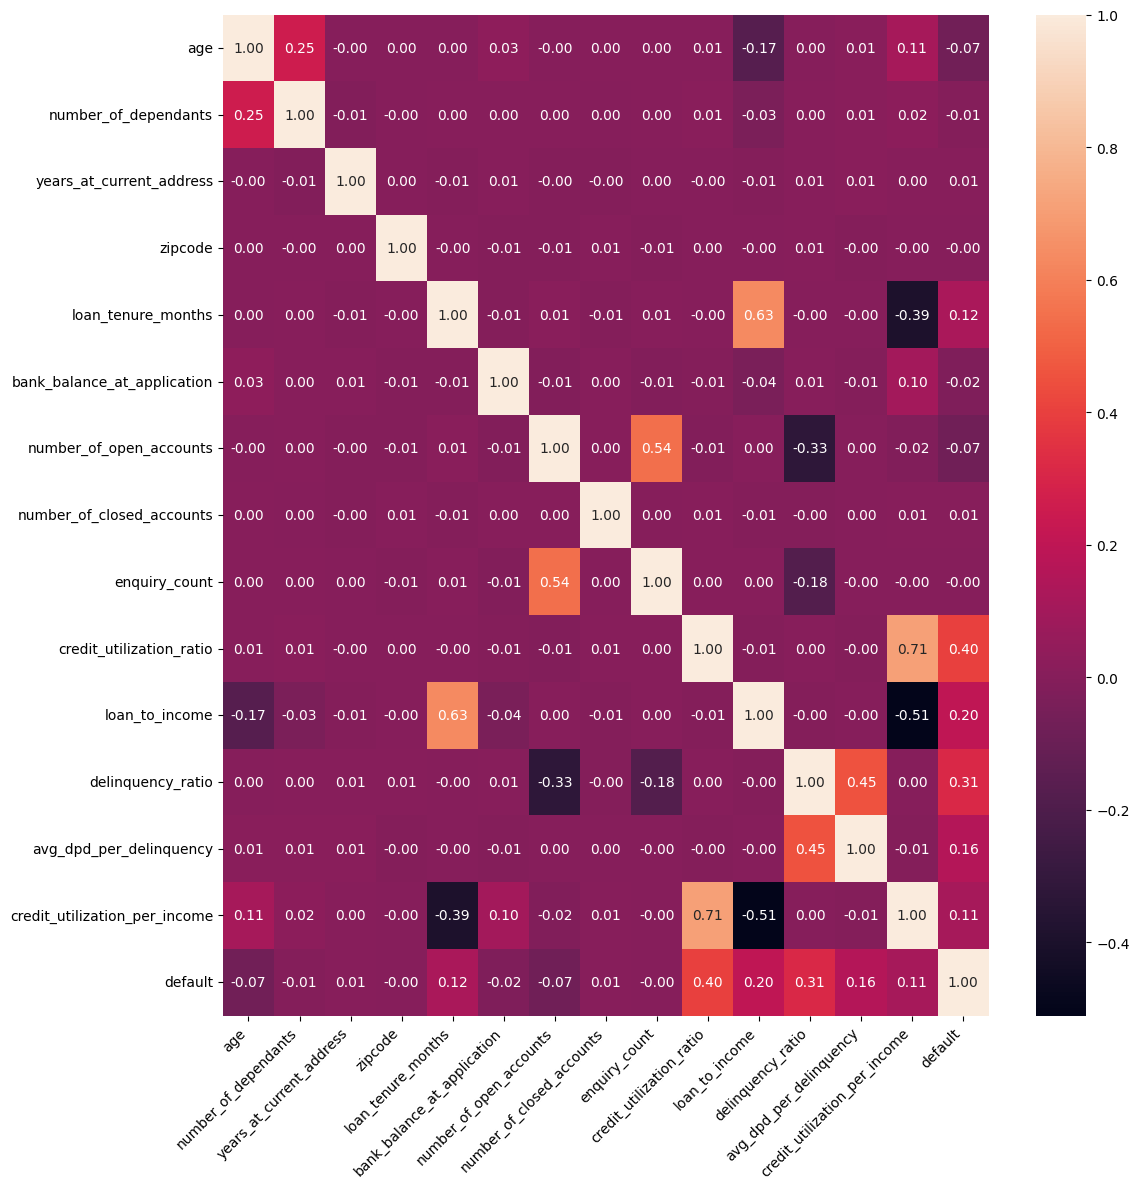

In [158]:
plt.figure(figsize=(12, 12))
cm = df_train_3[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot= True, fmt='0.2f')
plt.xticks(rotation = 45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [160]:
columns_categorical

['cust_id',
 'gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [162]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'count':'total', 'sum':'good'})
    grouped['bad'] = grouped['total']-grouped['good']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good']/total_good
    grouped['bad_pct'] = grouped['bad']/total_bad
    grouped['woe'] = np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct']-grouped['bad_pct'])*grouped['woe']

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()

    return grouped, total_iv

grouped, total_iv =  calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), 'loan_purpose', 'default')    

In [164]:
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7409,321,7088,0.10,0.21,-0.73,0.08
Education,5685,576,5109,0.18,0.15,0.18,0.01
Home,11245,1739,9506,0.54,0.28,0.67,0.17
Personal,13151,587,12564,0.18,0.37,-0.70,0.13


In [166]:
total_iv

np.float64(0.38725706860935977)

In [168]:
pd.cut

<function pandas.core.reshape.tile.cut(x, bins, right: 'bool' = True, labels=None, retbins: 'bool' = False, precision: 'int' = 3, include_lowest: 'bool' = False, duplicates: 'str' = 'raise', ordered: 'bool' = True)>

In [170]:
iv_values = {}
for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), feature, 'default')
        #iv_values[feature] = iv
    else:
        x_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([x_binned, y_train], axis=1), feature, 'default')
    iv_values[feature]=iv

iv_values

{'age': np.float64(0.07335774533067756),
 'gender': np.float64(5.262470527649633e-05),
 'marital_status': np.float64(0.0019566169243459813),
 'employment_status': np.float64(0.004165419262649794),
 'number_of_dependants': np.float64(0.003381494298496145),
 'residence_type': np.float64(0.24061873775338863),
 'years_at_current_address': np.float64(0.0029407082284517677),
 'city': np.float64(0.0015302052862612447),
 'state': np.float64(0.0012457500917579798),
 'zipcode': np.float64(0.0015129294474691924),
 'loan_purpose': np.float64(0.38725706860935977),
 'loan_type': np.float64(0.17628798087541556),
 'loan_tenure_months': np.float64(0.2286240652673015),
 'bank_balance_at_application': np.float64(0.0063767252658054885),
 'number_of_open_accounts': np.float64(0.07983252211507899),
 'number_of_closed_accounts': np.float64(0.0007745529170128115),
 'enquiry_count': np.float64(0.00874608809843976),
 'credit_utilization_ratio': np.float64(2.3740966566103463),
 'loan_to_income': np.float64(0.478

In [172]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.374
19,delinquency_ratio,0.726
18,loan_to_income,0.478
20,avg_dpd_per_delinquency,0.406
10,loan_purpose,0.387
5,residence_type,0.241
12,loan_tenure_months,0.229
21,credit_utilization_per_income,0.189
11,loan_type,0.176
14,number_of_open_accounts,0.080


In [174]:
selected_features_iv = [feature for feature, iv in iv_values.items() if iv>0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency',
 'credit_utilization_per_income']

### feature Encoding

In [177]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [179]:
X_train_reduced

,age,residence_type,loan_purpose,loan_type,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
318,0.481,Owned,Personal,Unsecured,0.226,0.000,0.414,0.091,0.400,0.550,0.204
10969,0.500,Mortgage,Auto,Secured,0.302,1.000,0.121,0.175,0.027,0.560,0.039
1654,0.481,Owned,Auto,Secured,0.528,1.000,0.131,0.182,0.000,0.000,0.041
10545,0.500,Mortgage,Personal,Unsecured,0.094,0.667,0.394,0.100,0.132,0.520,0.183
43712,0.404,Mortgage,Personal,Unsecured,0.302,0.333,0.364,0.110,0.000,0.000,0.161
...,...,...,...,...,...,...,...,...,...,...,...
17133,0.346,Rented,Personal,Unsecured,0.283,1.000,0.030,0.100,0.000,0.000,0.014
35238,0.404,Mortgage,Home,Secured,0.528,1.000,0.202,0.510,0.033,0.650,0.027
46298,0.865,Owned,Home,Secured,0.623,1.000,0.515,0.399,0.016,0.200,0.087
39083,0.288,Owned,Education,Secured,0.717,0.667,0.051,0.252,0.000,0.000,0.012


In [181]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)

In [183]:
X_train_encoded.head(3)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
318,0.481,0.226,0.000,0.414,0.091,0.400,0.550,0.204,True,False,False,False,True,True
10969,0.500,0.302,1.000,0.121,0.175,0.027,0.560,0.039,False,False,False,False,False,False
1654,0.481,0.528,1.000,0.131,0.182,0.000,0.000,0.041,True,False,False,False,False,False


### Atempt 1

1. Logistic Regression, RandomForest & XGB
2. No handling of class imbalance

In [186]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11421
           1       0.83      0.71      0.77      1074

    accuracy                           0.96     12495
   macro avg       0.90      0.85      0.87     12495
weighted avg       0.96      0.96      0.96     12495



In [188]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11421
           1       0.84      0.72      0.78      1074

    accuracy                           0.96     12495
   macro avg       0.91      0.85      0.88     12495
weighted avg       0.96      0.96      0.96     12495



In [189]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11421
           1       0.81      0.76      0.78      1074

    accuracy                           0.96     12495
   macro avg       0.89      0.87      0.88     12495
weighted avg       0.96      0.96      0.96     12495



In [190]:
from sklearn.model_selection import RandomizedSearchCV

# ------------------------------
# 2️⃣ Parameter distribution
# ------------------------------
param_dist = {
    'C': np.logspace(-4, 4, 20),
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']
}

# ------------------------------
# 3️⃣ Model + Random Search
# ------------------------------
log_reg = LogisticRegression(max_iter=10000)

random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,                 # number of random combinations
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ------------------------------
# 4️⃣ Fit and print results
# ------------------------------
random_search.fit(X_train_encoded, y_train)


print(f"\n🏆 Best Parameters: {random_search.best_params_}")
print(f"\n📦 Best Score:\n{random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits

🏆 Best Parameters: {'solver': 'lbfgs', 'C': np.float64(545.5594781168514)}

📦 Best Score:
0.7597961516636248
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11421
           1       0.83      0.73      0.78      1074

    accuracy                           0.96     12495
   macro avg       0.90      0.86      0.88     12495
weighted avg       0.96      0.96      0.96     12495



In [191]:
from sklearn.model_selection import RandomizedSearchCV

# ------------------------------
# 1️⃣ Define parameter distribution
# ------------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': np.logspace(-3, 0, 10),  # 0.001 → 1.0
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'reg_alpha': np.logspace(-4, 1, 6),  # L1 regularization
    'reg_lambda': np.logspace(-4, 1, 6), # L2 regularization
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [1, 2, 5, 10]  # useful for imbalanced data
}

# ------------------------------
# 3️⃣ Model + Random Search
# ------------------------------
xgb = XGBClassifier()

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,                 # number of random combinations
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ------------------------------
# 4️⃣ Fit and print results
# ------------------------------
random_search.fit(X_train_encoded, y_train)


print(f"\n🏆 Best Parameters: {random_search.best_params_}")
print(f"\n📦 Best Score:\n{random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits

🏆 Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 2, 'reg_lambda': np.float64(0.1), 'reg_alpha': np.float64(1.0), 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': np.float64(0.046415888336127774), 'gamma': 0.1, 'colsample_bytree': 0.7}

📦 Best Score:
0.78751386846719
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11421
           1       0.77      0.84      0.80      1074

    accuracy                           0.96     12495
   macro avg       0.88      0.91      0.89     12495
weighted avg       0.97      0.96      0.97     12495



### Atempt 2

1. Logistic Regression & XGB
2. handle Class imbalance using undersampling

In [195]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_encoded, y_train)

y_train_rus.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [196]:
model = LogisticRegression()
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.92      0.95     11421
           1       0.52      0.96      0.67      1074

    accuracy                           0.92     12495
   macro avg       0.76      0.94      0.81     12495
weighted avg       0.95      0.92      0.93     12495



In [198]:
model = XGBClassifier()
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11421
           1       0.56      0.96      0.71      1074

    accuracy                           0.93     12495
   macro avg       0.78      0.94      0.83     12495
weighted avg       0.96      0.93      0.94     12495



### Atempt 2

1. Logistic Regression
2. handle Class imbalance using SMOTE Tomek
3. Parameter tuning using optuna

In [204]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)

X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)

y_train_smt.value_counts()

default
0    34187
1    34187
Name: count, dtype: int64

In [205]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11421
           1       0.56      0.95      0.70      1074

    accuracy                           0.93     12495
   macro avg       0.78      0.94      0.83     12495
weighted avg       0.96      0.93      0.94     12495



In [208]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [210]:
# Define objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Regularization strength
        'solver': trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Convergence tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class balance
    }
    
    model = LogisticRegression(**param, max_iter=1000, random_state=42)

    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

# Run optimization
study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

# Print best results
print("\n✅ Best Parameters:")
for key, val in study_logistic.best_params.items():
    print(f"{key}: {val}")

print(f"\n🎯 Best Cross-Validation F1 Score: {study_logistic.best_value:.4f}")



[I 2025-11-27 13:00:54,882] A new study created in memory with name: no-name-25196124-7916-427e-9551-19ff089e3043
[I 2025-11-27 13:00:55,099] Trial 0 finished with value: 0.9446868884754062 and parameters: {'C': 1136.8820155229819, 'solver': 'saga', 'tol': 5.855561468636803e-06, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9446868884754062.
[I 2025-11-27 13:00:55,229] Trial 1 finished with value: 0.944627534354709 and parameters: {'C': 32.066671949367965, 'solver': 'liblinear', 'tol': 0.002498582000009357, 'class_weight': None}. Best is trial 0 with value: 0.9446868884754062.
[I 2025-11-27 13:00:55,367] Trial 2 finished with value: 0.8715562052385435 and parameters: {'C': 0.00036164409292121325, 'solver': 'sag', 'tol': 2.0514879264672553e-05, 'class_weight': None}. Best is trial 0 with value: 0.9446868884754062.
[I 2025-11-27 13:00:55,472] Trial 3 finished with value: 0.9351339440701025 and parameters: {'C': 0.03360756519321845, 'solver': 'lbfgs', 'tol': 3.076402168299899


✅ Best Parameters:
C: 605.1690513225499
solver: sag
tol: 3.097975270745434e-05
class_weight: None

🎯 Best Cross-Validation F1 Score: 0.9447


In [212]:
print('Best trial:')
trial = study_logistic.best_trial
print(' F1-score: {}'.format(trial.value))
print(' Params: ')
for key, value in trial.params.items():
    print(' {} : {}'.format(key, value))

best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)

print(report)

Best trial:
 F1-score: 0.9447014955410271
 Params: 
 C : 605.1690513225499
 solver : sag
 tol : 3.097975270745434e-05
 class_weight : None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11421
           1       0.56      0.95      0.71      1074

    accuracy                           0.93     12495
   macro avg       0.78      0.94      0.83     12495
weighted avg       0.96      0.93      0.94     12495



#### Attempt 4

1. XGBoost
2. Handle Class Imbalance Using SMOTE Tomek
3. Parameter tunning uisng optuna

In [215]:
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity' : 0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),  # L1 regularization
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True), # L2 regularization
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 2, 3, 5, 10]), # handle imbalance
        'random_state': 42,
        'use_label_encoder': False
        
    }

    model = XGBClassifier(**param)

    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

# Run optimization
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

# Print results
print("\n✅ Best Parameters for XGBoost:")
for k, v in study_xgb.best_params.items():
    print(f"{k}: {v}")

print(f"\n🎯 Best Cross-Validation F1 Score: {study_xgb.best_value:.4f}")

[I 2025-11-27 13:01:11,598] A new study created in memory with name: no-name-1c46f819-300c-4795-adcb-156da1598e93
[I 2025-11-27 13:01:12,991] Trial 0 finished with value: 0.7696822113727575 and parameters: {'n_estimators': 791, 'learning_rate': 0.02299891696729535, 'max_depth': 6, 'subsample': 0.8540894284717553, 'colsample_bytree': 0.7346931321260177, 'gamma': 3.5197094291113586, 'reg_alpha': 0.0010914346611262276, 'reg_lambda': 0.0009225471949886919, 'min_child_weight': 3, 'scale_pos_weight': 2}. Best is trial 0 with value: 0.7696822113727575.
[I 2025-11-27 13:01:13,699] Trial 1 finished with value: 0.7768884504022191 and parameters: {'n_estimators': 701, 'learning_rate': 0.19946415972408896, 'max_depth': 7, 'subsample': 0.6691665694139524, 'colsample_bytree': 0.6056995714938247, 'gamma': 3.2823100368174924, 'reg_alpha': 0.00013249524462539405, 'reg_lambda': 0.04929204550180352, 'min_child_weight': 10, 'scale_pos_weight': 2}. Best is trial 1 with value: 0.7768884504022191.
[I 2025-11


✅ Best Parameters for XGBoost:
n_estimators: 804
learning_rate: 0.10530189075710904
max_depth: 5
subsample: 0.6542622545154225
colsample_bytree: 0.7485767539555416
gamma: 0.22253152236224763
reg_alpha: 0.0015756029567248644
reg_lambda: 0.0006214380235036532
min_child_weight: 5
scale_pos_weight: 2

🎯 Best Cross-Validation F1 Score: 0.7872


In [219]:
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)

print(report)



              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11421
           1       0.56      0.95      0.71      1074

    accuracy                           0.93     12495
   macro avg       0.78      0.94      0.83     12495
weighted avg       0.96      0.93      0.94     12495



In [221]:
from sklearn.metrics import  roc_curve
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]


fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:10], tpr[:10], thresholds[:10]

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.  , 0.  , 0.16, 0.16, 0.17, 0.17, 0.19, 0.19, 0.25, 0.25]),
 array([inf,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.]))

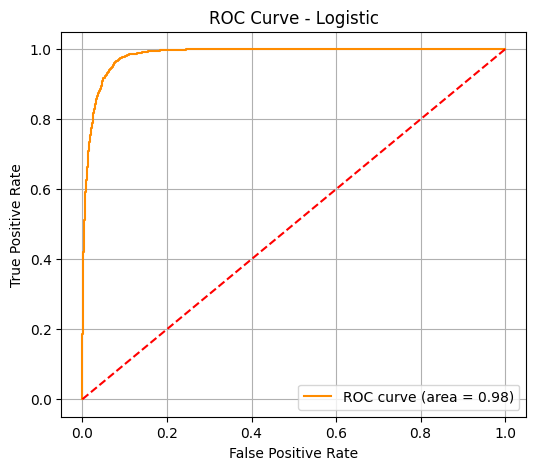

In [223]:
from sklearn.metrics import auc
area = auc (fpr, tpr)
# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' %area)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic')
plt.legend()
plt.grid(True)
plt.show()

#### Model Evaluation: Rankorder & KS Statistic

In [226]:
probabities = best_model_logistic.predict_proba(X_test_encoded)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})

df_eval.head(3)

,Default Truth,Default Probability
37921,0,0.000
16114,0,0.423
5539,0,0.000


In [228]:
df_eval['Decile']= pd.qcut(df_eval['Default Probability'], 10, labels= False, duplicates='drop')

df_eval.head(3)

,Default Truth,Default Probability,Decile
37921,0,0.000,1
16114,0,0.423,8
5539,0,0.000,4


In [230]:
df_grouped = df_eval.groupby('Decile').apply(lambda x : pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events':x['Default Truth'].sum(),
    'Non-events':x['Default Truth'].count()-x['Default Truth'].sum(),
    
}))

df_grouped.reset_index(inplace=True)
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1249.000
2,2,0.000,0.000,0.000,1250.000
3,3,0.000,0.000,0.000,1249.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.004,0.000,1249.000
6,6,0.004,0.025,1.000,1248.000
7,7,0.025,0.196,13.000,1237.000
8,8,0.196,0.815,158.000,1091.000
9,9,0.815,1.000,902.000,348.000


In [232]:
df_grouped['Event Rate']= df_grouped['Events']*100/(df_grouped['Events']+df_grouped['Non-events'])
df_grouped['Non-events Rate']= df_grouped['Non-events']*100/(df_grouped['Events']+df_grouped['Non-events'])
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-events Rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.000,0.000,1249.000,0.000,100.000
2,2,0.000,0.000,0.000,1250.000,0.000,100.000
3,3,0.000,0.000,0.000,1249.000,0.000,100.000
4,4,0.000,0.001,0.000,1250.000,0.000,100.000
5,5,0.001,0.004,0.000,1249.000,0.000,100.000
6,6,0.004,0.025,1.000,1248.000,0.080,99.920
7,7,0.025,0.196,13.000,1237.000,1.040,98.960
8,8,0.196,0.815,158.000,1091.000,12.650,87.350
9,9,0.815,1.000,902.000,348.000,72.160,27.840


In [234]:
df_grouped= df_grouped.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-events Rate
0,9,0.815,1.000,902.000,348.000,72.160,27.840
1,8,0.196,0.815,158.000,1091.000,12.650,87.350
2,7,0.025,0.196,13.000,1237.000,1.040,98.960
3,6,0.004,0.025,1.000,1248.000,0.080,99.920
4,5,0.001,0.004,0.000,1249.000,0.000,100.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000
6,3,0.000,0.000,0.000,1249.000,0.000,100.000
7,2,0.000,0.000,0.000,1250.000,0.000,100.000
8,1,0.000,0.000,0.000,1249.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [236]:
df_grouped['Cum Events']= df_grouped['Events'].cumsum()
df_grouped['Cum Non-events']= df_grouped['Non-events'].cumsum()
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-events Rate,Cum Events,Cum Non-events
0,9,0.815,1.000,902.000,348.000,72.160,27.840,902.000,348.000
1,8,0.196,0.815,158.000,1091.000,12.650,87.350,1060.000,1439.000
2,7,0.025,0.196,13.000,1237.000,1.040,98.960,1073.000,2676.000
3,6,0.004,0.025,1.000,1248.000,0.080,99.920,1074.000,3924.000
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5173.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6423.000
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,7672.000
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,8922.000
8,1,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,10171.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11421.000


In [238]:
df_grouped['Cum Event Rate'] = df_grouped['Cum Events']*100/df_grouped['Events'].sum()
df_grouped['Cum Non-event Rate'] = df_grouped['Cum Non-events']*100/df_grouped['Non-events'].sum()
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-events Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.815,1.000,902.000,348.000,72.160,27.840,902.000,348.000,83.985,3.047
1,8,0.196,0.815,158.000,1091.000,12.650,87.350,1060.000,1439.000,98.696,12.600
2,7,0.025,0.196,13.000,1237.000,1.040,98.960,1073.000,2676.000,99.907,23.431
3,6,0.004,0.025,1.000,1248.000,0.080,99.920,1074.000,3924.000,100.000,34.358
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5173.000,100.000,45.294
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6423.000,100.000,56.239
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,7672.000,100.000,67.175
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,8922.000,100.000,78.119
8,1,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,10171.000,100.000,89.055
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11421.000,100.000,100.000


In [240]:
df_grouped['KS'] = abs(df_grouped['Cum Event Rate']-df_grouped['Cum Non-event Rate'])
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-events Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.815,1.000,902.000,348.000,72.160,27.840,902.000,348.000,83.985,3.047,80.938
1,8,0.196,0.815,158.000,1091.000,12.650,87.350,1060.000,1439.000,98.696,12.600,86.097
2,7,0.025,0.196,13.000,1237.000,1.040,98.960,1073.000,2676.000,99.907,23.431,76.476
3,6,0.004,0.025,1.000,1248.000,0.080,99.920,1074.000,3924.000,100.000,34.358,65.642
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5173.000,100.000,45.294,54.706
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6423.000,100.000,56.239,43.761
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,7672.000,100.000,67.175,32.825
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,8922.000,100.000,78.119,21.881
8,1,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,10171.000,100.000,89.055,10.945
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11421.000,100.000,100.000,0.000


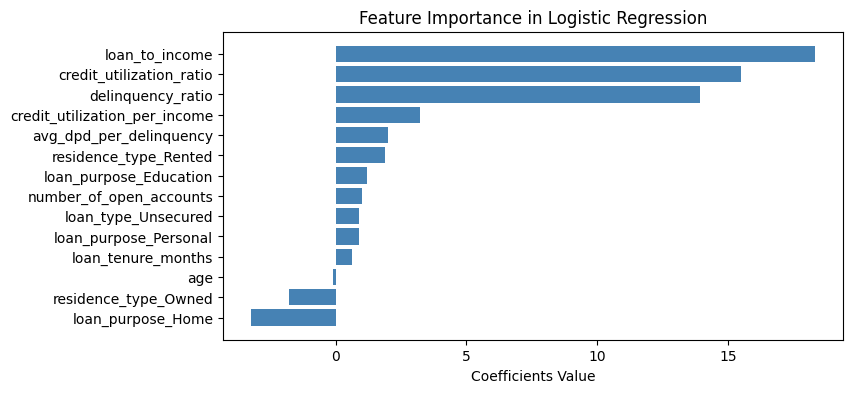

In [242]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color = 'steelblue')
plt.xlabel('Coefficients Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [244]:
from joblib import dump

model_data = {
    'model' : final_model,
    'features': X_train_encoded.columns,
    'scaler':scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data.joblib']

#### Exacise  Attempt 1: Use internet/ChatGPT to do some research and write code to use BayesianOptimization to find best parameters for logistic regression.

In [247]:
# -----------------------------------------
# 🔹 1. Import Libraries
# -----------------------------------------
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from bayes_opt import BayesianOptimization

In [249]:
# -----------------------------------------------------------
# 2️⃣ Objective Function
# -----------------------------------------------------------
def evaluate_model(C, tol):
    """
    Objective function for Bayesian Optimization.
    Uses X_train_smt, y_train_smt from your workspace.
    """
    model = LogisticRegression(
        C=float(C),
        tol=float(tol),
        solver='lbfgs',
        class_weight='balanced',
        max_iter=1000
    )
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_smt, y_train_smt, 
                            cv=cv, scoring='f1_macro', n_jobs=-1).mean()
    return score

In [251]:
# -----------------------------------------------------------
# 3️⃣ Define Hyperparameter Search Space
# -----------------------------------------------------------
pbounds = {
    'C': (1e-4, 1e4),   # Regularization strength
    'tol': (1e-6, 1e-1) # Convergence tolerance
}

In [253]:
# -----------------------------------------------------------
# 4️⃣ Run Bayesian Optimization
# -----------------------------------------------------------
optimizer = BayesianOptimization(
    f=evaluate_model,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,   # Initial random points
    n_iter=25        # Iterations for exploration
)

# -----------------------------------------------------------
# 5️⃣ Best Parameters
# -----------------------------------------------------------
print("\n✅ Best Parameters Found:")
print(optimizer.max)

|   iter    |  target   |     C     |    tol    |
-------------------------------------------------
| 1         | 0.7711592 | 3745.4012 | 0.0950714 |
| 2         | 0.7711592 | 7319.9394 | 0.0598662 |
| 3         | 0.9151373 | 1560.1864 | 0.0156002 |
| 4         | 0.7711592 | 580.83621 | 0.0866177 |
| 5         | 0.7711592 | 6011.1501 | 0.0708075 |
| 6         | 0.9371038 | 1559.3361 | 0.0022347 |
| 7         | 0.7711592 | 1555.3447 | 0.1       |
| 8         | 0.9447307 | 1563.4249 | 1e-06     |
| 9         | 0.7711592 | 1565.5542 | 0.1       |
| 10        | 0.9447307 | 1562.2188 | 1e-06     |
| 11        | 0.7711592 | 4558.6983 | 0.0766963 |
| 12        | 0.7711592 | 5864.8021 | 0.0980863 |
| 13        | 0.7711592 | 890.89485 | 0.0588618 |
| 14        | 0.9048350 | 4002.1585 | 0.0203456 |
| 15        | 0.7711592 | 3999.8991 | 0.0685132 |
| 16        | 0.9447307 | 4003.9883 | 1e-06     |
| 17        | 0.7711592 | 4006.1018 | 0.1       |
| 18        | 0.7711592 | 1557.9671 | 0.1       |


In [254]:
# -----------------------------------------------------------
# 1️⃣ Imports
# -----------------------------------------------------------
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# -----------------------------------------------------------
# 2️⃣ Define XGBoost Model
# -----------------------------------------------------------
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# -----------------------------------------------------------
# 3️⃣ Parameter Grid
# -----------------------------------------------------------
param_grid = {
    'n_estimators': [100, 200, 300],         # Number of boosting rounds
    'max_depth': [3, 5, 7],                  # Depth of each tree
    'learning_rate': [0.01, 0.05, 0.1],      # Step size shrinkage
    'subsample': [0.8, 1.0],                 # Row sampling
    'colsample_bytree': [0.8, 1.0],          # Feature sampling
    'gamma': [0, 0.1, 0.3],                  # Minimum loss reduction
    'reg_lambda': [1, 5, 10],                # L2 regularization
}

# -----------------------------------------------------------
# 4️⃣ Grid Search Setup
# -----------------------------------------------------------
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=make_scorer(f1_score, average='macro'),
    cv=3,
    n_jobs=-1,
    verbose=2
)

# -----------------------------------------------------------
# 5️⃣ Run Grid Search
# -----------------------------------------------------------
grid_search.fit(X_train_smt, y_train_smt)

# -----------------------------------------------------------
# 6️⃣ Best Parameters & Score
# -----------------------------------------------------------
print("\n✅ Best Parameters Found:")
print(grid_search.best_params_)

print("\n🏆 Best F1 Score (Macro):", grid_search.best_score_)

# -----------------------------------------------------------
# 7️⃣ Best Model
# -----------------------------------------------------------
best_xgb = grid_search.best_estimator_

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
[CV] END .............................C=0.0001, solver=lbfgs; total time=   0.0s
[CV] END ................C=0.08858667904100823, solver=lbfgs; total time=   0.0s
[CV] END ...............C=1438.44988828766, solver=liblinear; total time=   0.1s
[CV] END ..................C=11.288378916846883, solver=saga; total time=   0.1s
[CV] END ...................C=4.281332398719396, solver=saga; total time=   0.1s
[CV] END ...............C=0.0006951927961775605, solver=saga; total time=   0.1s
[CV] END ...............C=206.913808111479, solver=liblinear; total time=   0.1s
[CV] END ........................C=10000.0, solver=newton-cg; total time=   0.1s
[CV] END .........C=0.00026366508987303583, solver=newton-cg; total time=   0.0s
[CV] END .................C=0.03359818286283781, solver=saga; total time=   0.1s
[CV] END ..................C=4.281332398719396, solver=lbfgs; total time=   0.0s
[CV] END .........................C=0.0001, s

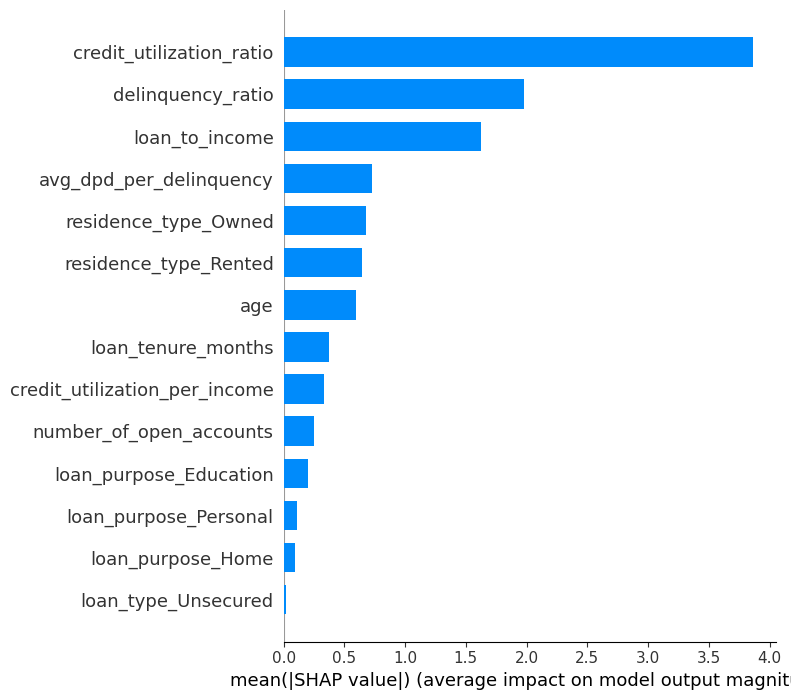

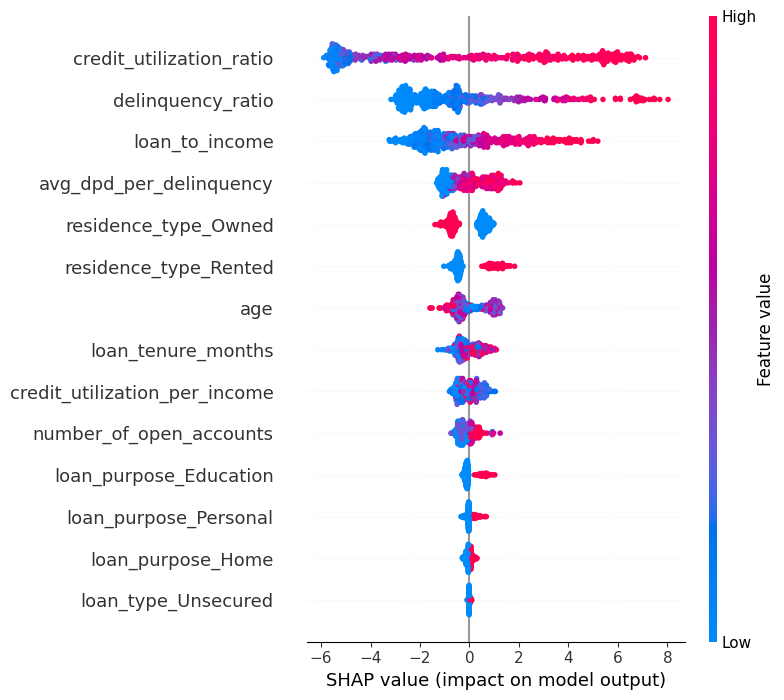

In [268]:
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

# -------------------------------
# 1️⃣ Load or use your best XGBoost model
# -------------------------------
# Example: if your best model variable name is 'best_xgb_model'
# (Replace this with your trained model variable)
model = best_xgb  

# -------------------------------
# 2️⃣ Prepare data for SHAP
# -------------------------------
X_sample = X_train_smt.sample(500, random_state=42)  # take a small sample for faster explanation
y_sample = y_train_smt.loc[X_sample.index]

# -------------------------------
# 3️⃣ Create SHAP Explainer
# -------------------------------
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# -------------------------------
# 4️⃣ Visualizations
# -------------------------------
# Summary plot – shows feature importance & direction of impact
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# Detailed beeswarm plot – impact of each feature per sample
shap.summary_plot(shap_values, X_sample)

# -------------------------------
# 5️⃣ Optional: Explain a single prediction
# -------------------------------
i = 0  # choose an instance index
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[i, :], X_sample.iloc[i, :])

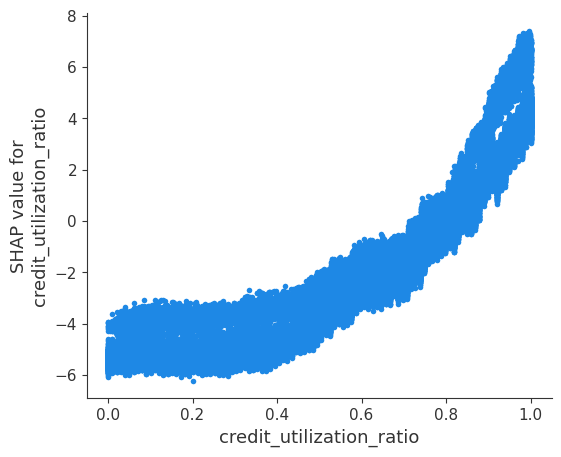

In [270]:
# 1️⃣ Ensure you use the same dataset as for model training
X_sample = X_train_smt  # or X_test if you want test explainability

# 2️⃣ Initialize the TreeExplainer
explainer = shap.TreeExplainer(best_xgb)

# 3️⃣ Compute SHAP values (works for both newer and older SHAP versions)
shap_values = explainer(X_sample)

# 4️⃣ If SHAP returns Explanation object, access .values for plotting
if isinstance(shap_values, shap._explanation.Explanation):
    shap_values_matrix = shap_values.values
else:
    shap_values_matrix = shap_values

# 5️⃣ Generate dependence plot
shap.dependence_plot(
    "credit_utilization_ratio",
    shap_values_matrix,
    X_sample,
    interaction_index=None
)

In [271]:
X_test_encoded

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
37921,0.173,0.094,0.667,0.051,0.082,0.000,0.000,0.026,False,True,False,False,True,True
16114,0.712,0.264,1.000,0.980,0.231,0.008,0.100,0.258,True,False,True,False,False,False
5539,0.596,0.038,1.000,0.596,0.093,0.000,0.000,0.289,True,False,False,False,True,True
29703,0.365,0.698,0.333,0.192,0.315,0.021,0.600,0.039,False,False,True,False,False,False
24870,0.192,0.302,0.000,0.535,0.203,0.000,0.000,0.156,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27074,0.404,0.340,0.333,0.747,0.340,0.000,0.000,0.144,False,True,True,False,False,False
27518,0.558,0.283,0.333,0.212,0.058,0.231,0.540,0.131,False,True,False,False,True,True
32988,0.038,0.679,0.000,0.152,0.809,0.172,0.430,0.014,True,False,False,True,False,False
10562,0.423,0.038,0.000,0.525,0.105,0.080,0.600,0.238,False,True,False,False,True,True


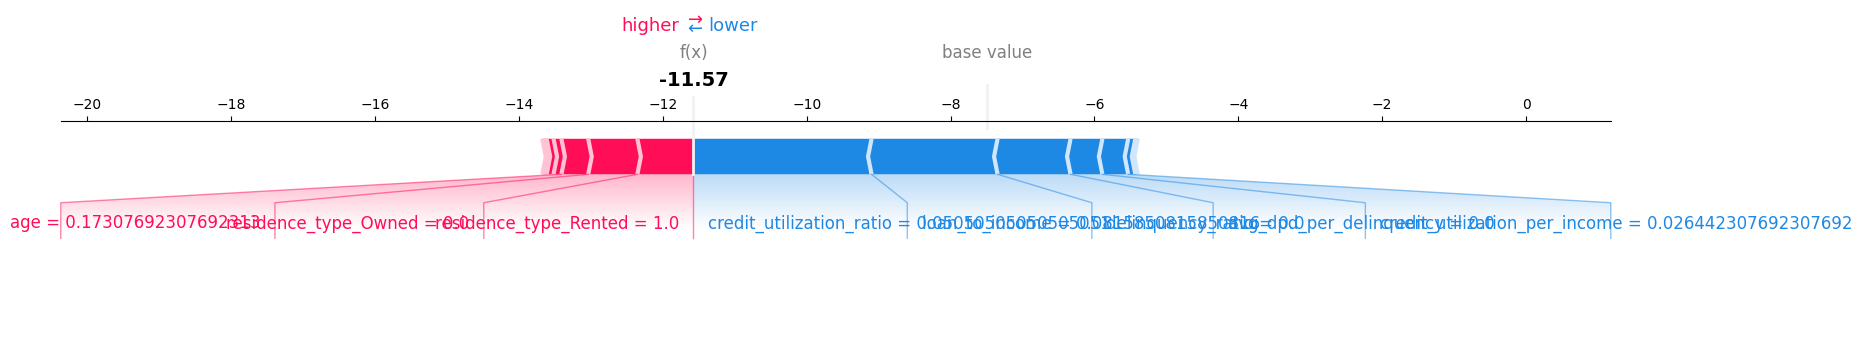

In [274]:
# Convert all columns to float
X_test_numeric = X_test_encoded.astype(float)

# Now create the explainer
explainer = shap.Explainer(best_xgb, X_test_numeric)

# Pick a single instance
i = 0
shap_values_single = explainer(X_test_numeric.iloc[i:i+1])

# Draw force plot
shap.force_plot(
    explainer.expected_value,
    shap_values_single.values,
    X_test_numeric.iloc[i:i+1],
    matplotlib=True
)

In [276]:
print(X_test_encoded.dtypes)


age                              float64
loan_tenure_months               float64
number_of_open_accounts          float64
credit_utilization_ratio         float64
loan_to_income                   float64
delinquency_ratio                float64
avg_dpd_per_delinquency          float64
credit_utilization_per_income    float64
residence_type_Owned                bool
residence_type_Rented               bool
loan_purpose_Education              bool
loan_purpose_Home                   bool
loan_purpose_Personal               bool
loan_type_Unsecured                 bool
dtype: object
